In [1]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
species = "hsapiens"
index_dir = project_dir / "Index" / "human"
analysis_name = "Analysis_6"
analysis_dir = Path.cwd() 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
def get_kb_dir(project_dir: Path, assay: str, type: str = None) -> Path:
    if type is None:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / "sampled_out"
    else:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / f"sampled_{type}_out"
    return kb_dir

In [6]:
data_10x = plotting.init_processing('10x', get_kb_dir(project_dir, '10x'), '10X Genomics')
data_polyT = plotting.init_processing('polyT', get_kb_dir(project_dir, 'parse', type = 'polyT'), "Parse 3\'")
data_randO = plotting.init_processing('randO', get_kb_dir(project_dir, 'parse', type = 'randO'), 'Parse Random Oligo')
data_parse = plotting.init_processing('parse', get_kb_dir(project_dir, 'parse'), "Parse", modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq running in background for: 10x
PreSeq output not ready for '10X Genomics' — skipping.


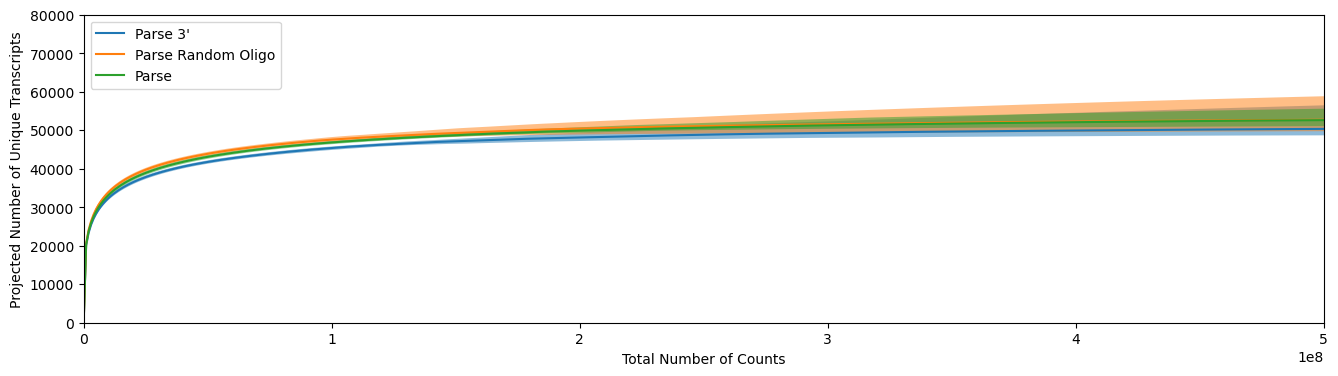

In [7]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

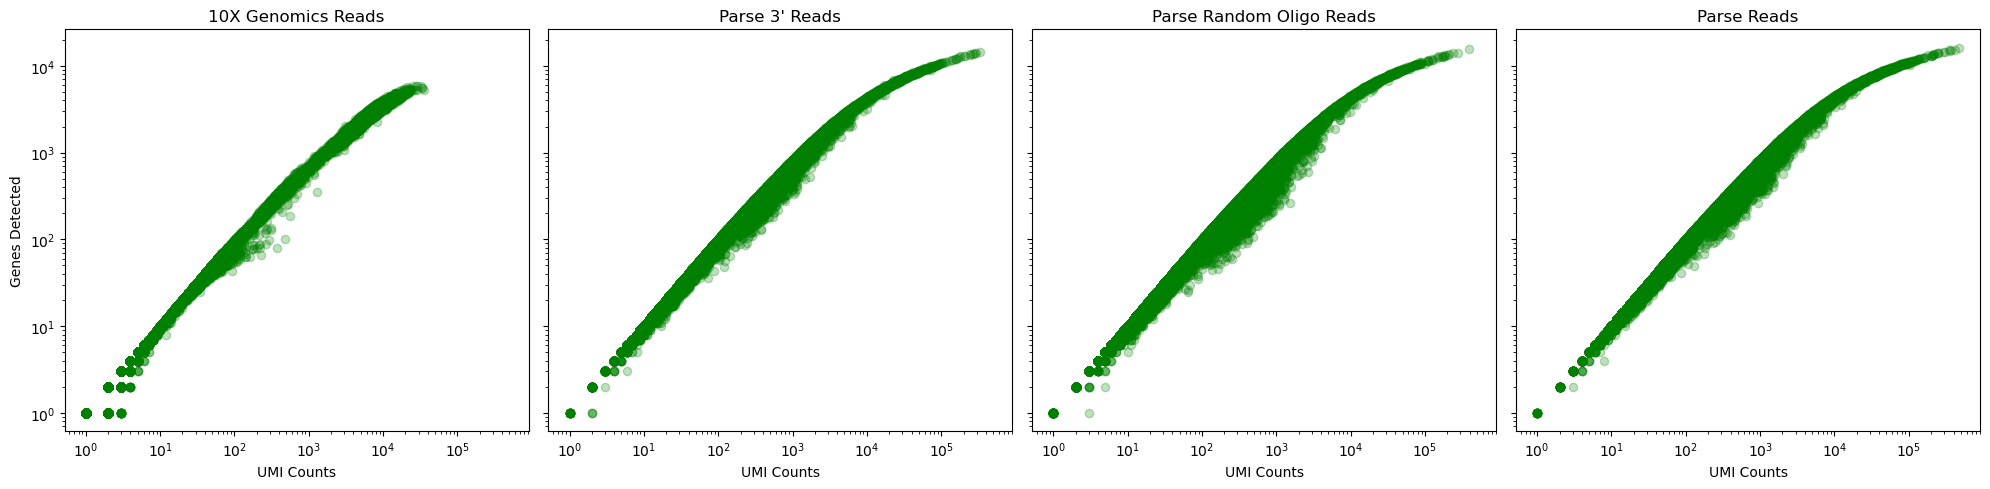

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(raw_datasets):
    plotting.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()

In [9]:
# Path to save gene metadata so don't need to query Ensembl more than once
gene_info = plotting.query_ensembl(analysis_dir, index_dir=index_dir, overwrite=True)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


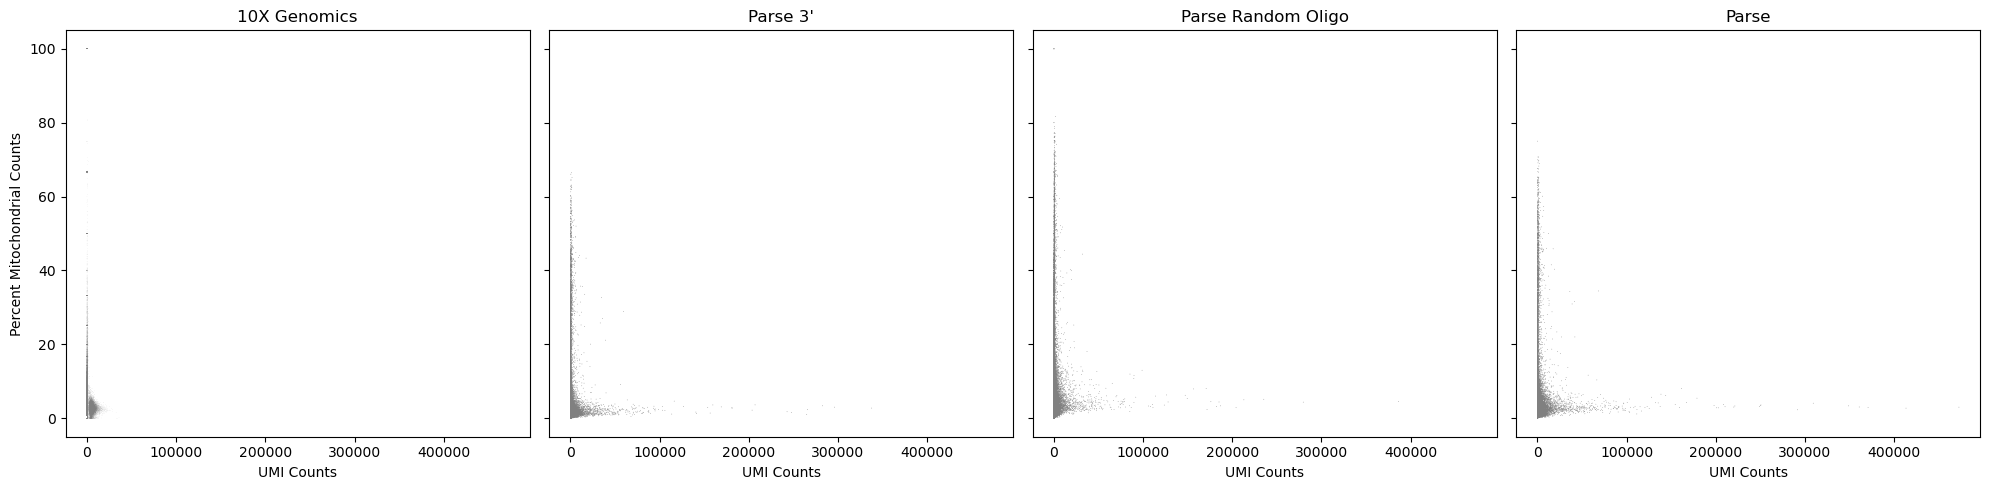

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True,sharex=True)
for i, data in enumerate(raw_datasets):
    plotting.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()

13,644 cells passed the 300 UMI threshold for 10X Genomics


10,634 cells passed the 400 UMI threshold for Parse 3'


9,025 cells passed the 400 UMI threshold for Parse Random Oligo


11,275 cells passed the 400 UMI threshold for Parse


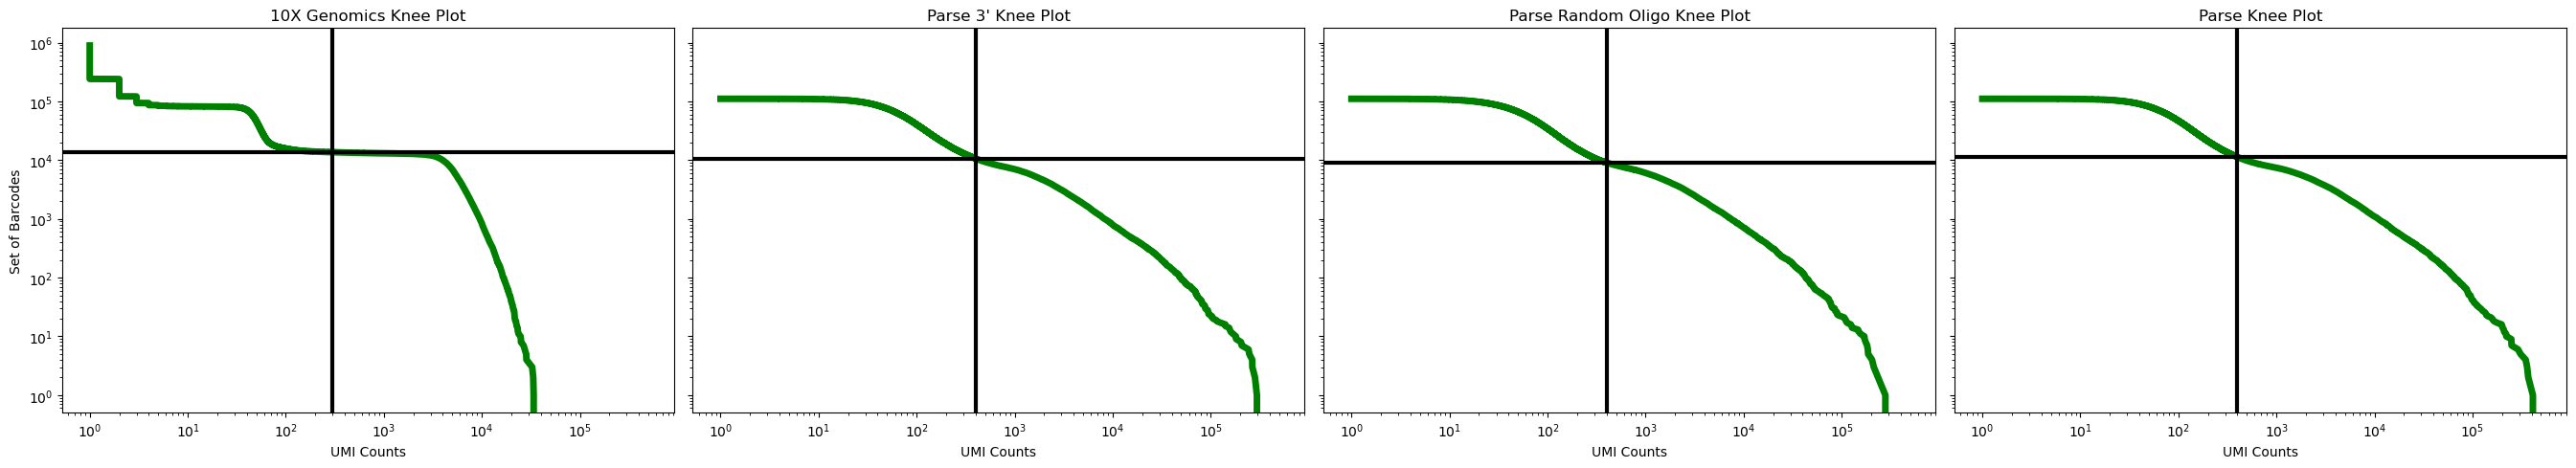

In [16]:
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

cutoffs = [300, 400, 400, 400]

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()

In [17]:
full_gene_info_path = project_dir / analysis_dir 
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)

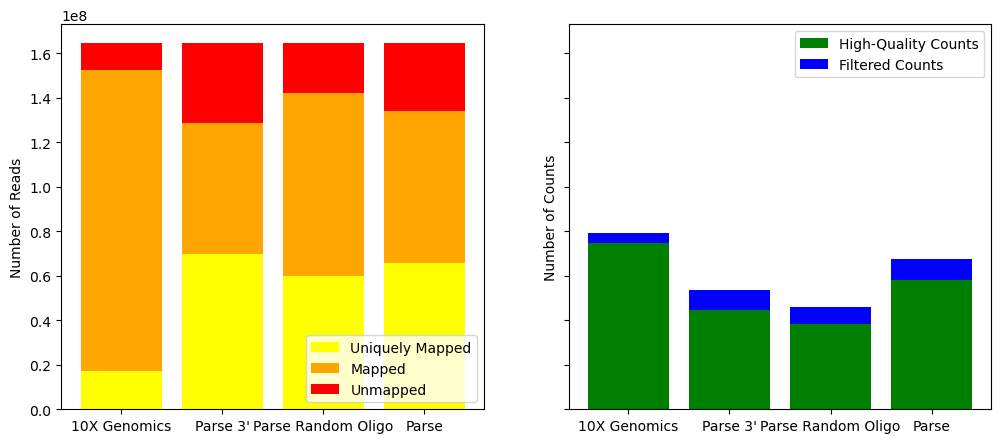

In [18]:
plotting.plot_filtering_metrics(datasets)

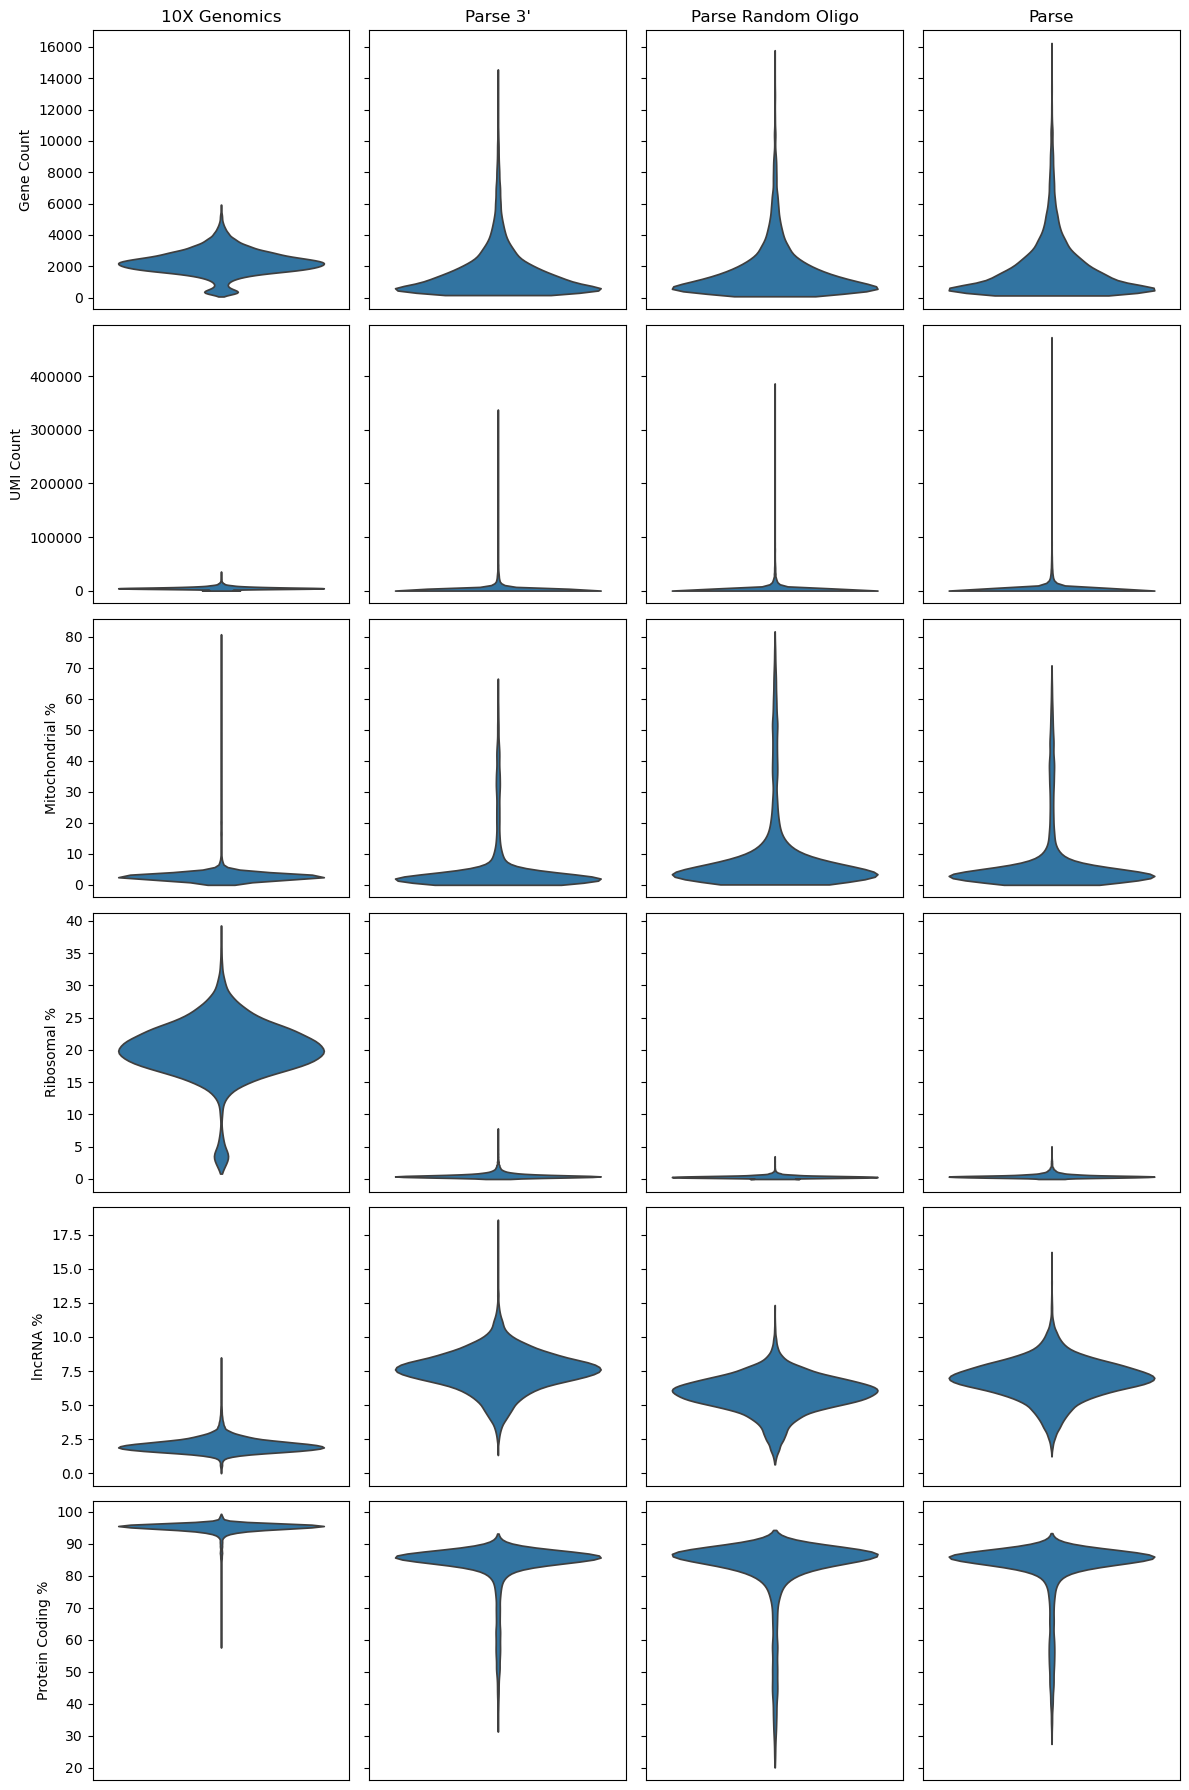

In [19]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))

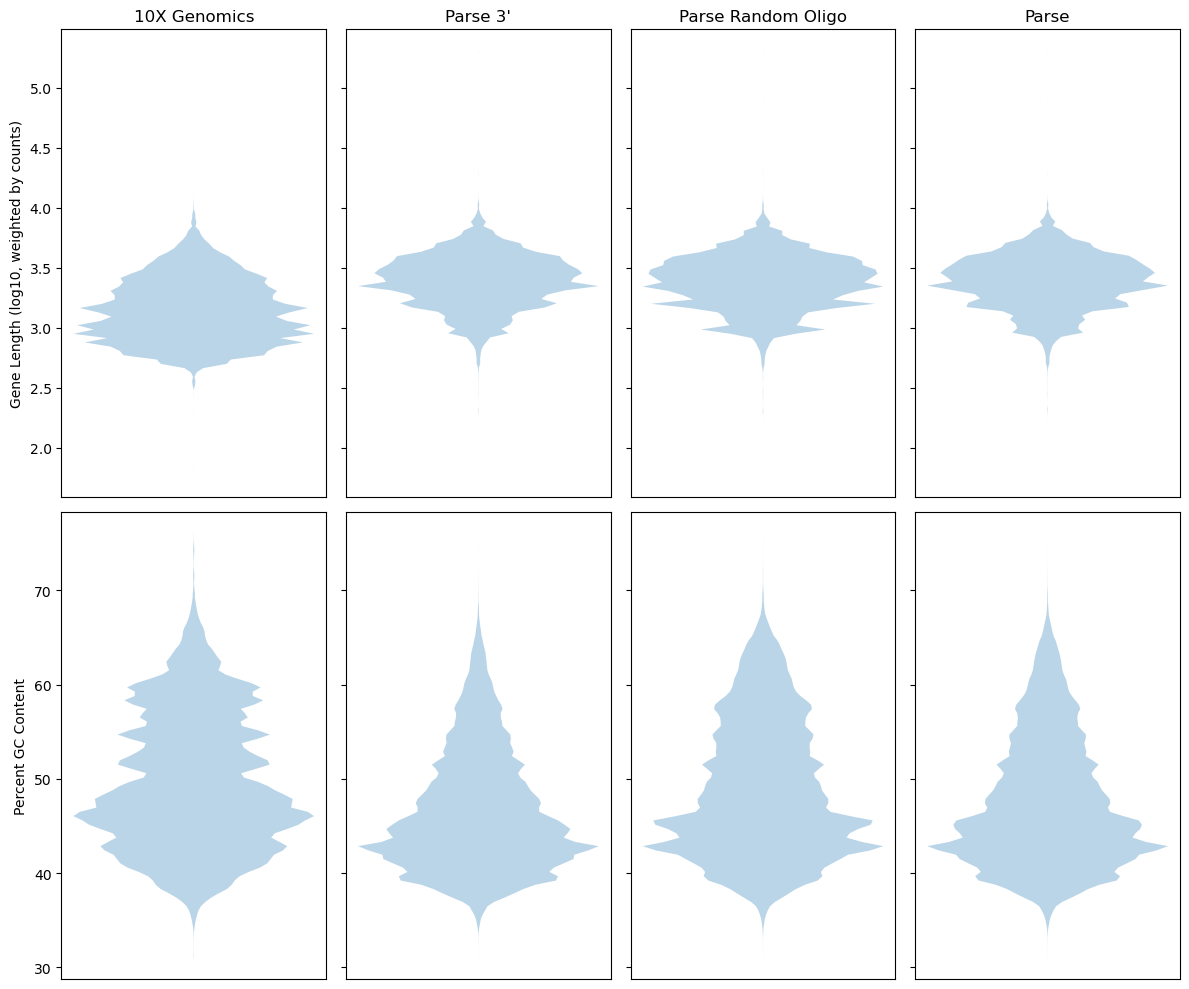

In [20]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)

# Read/Gene Comparisons

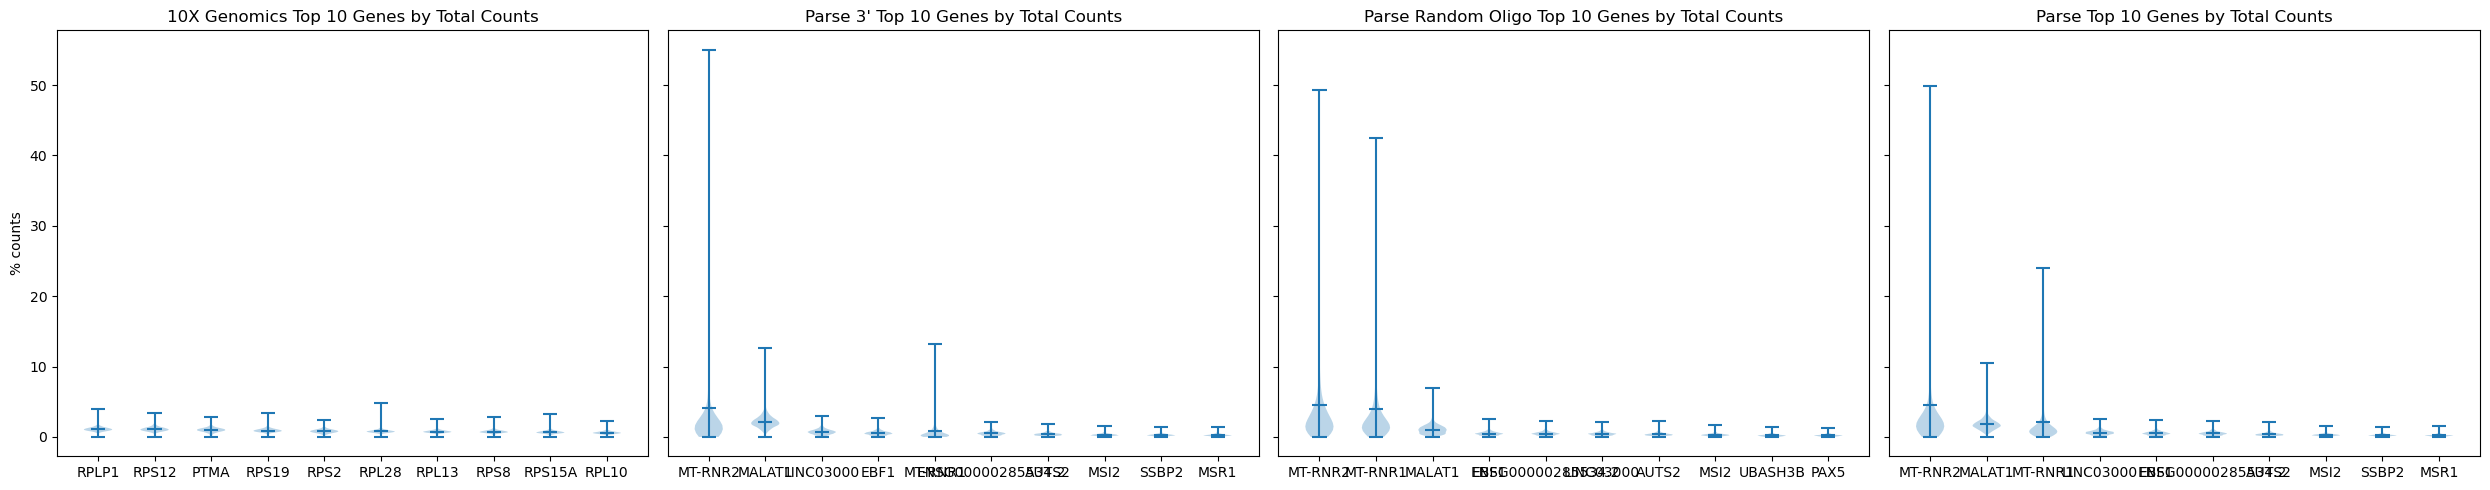

In [25]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

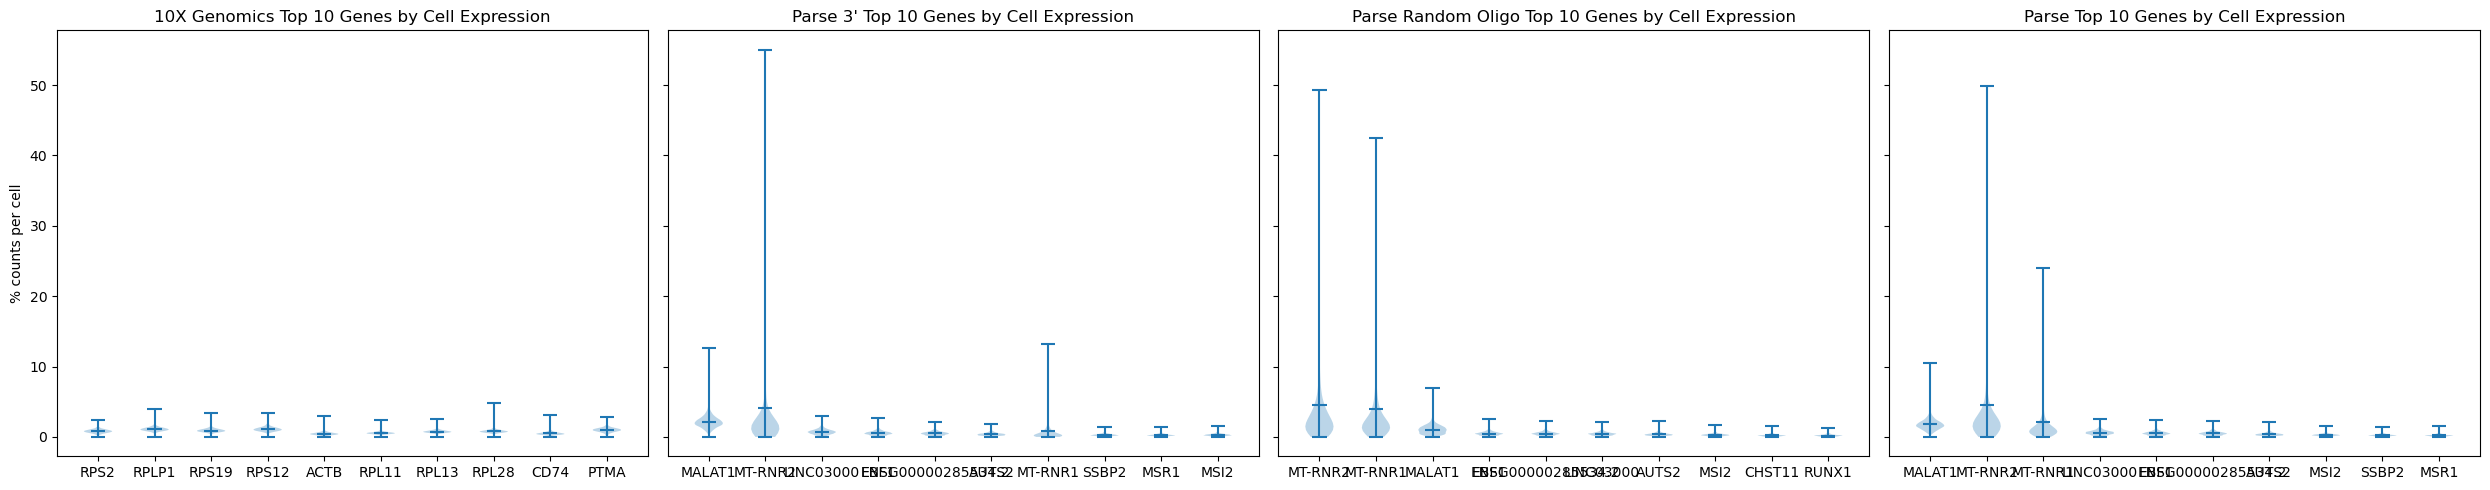

In [26]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()

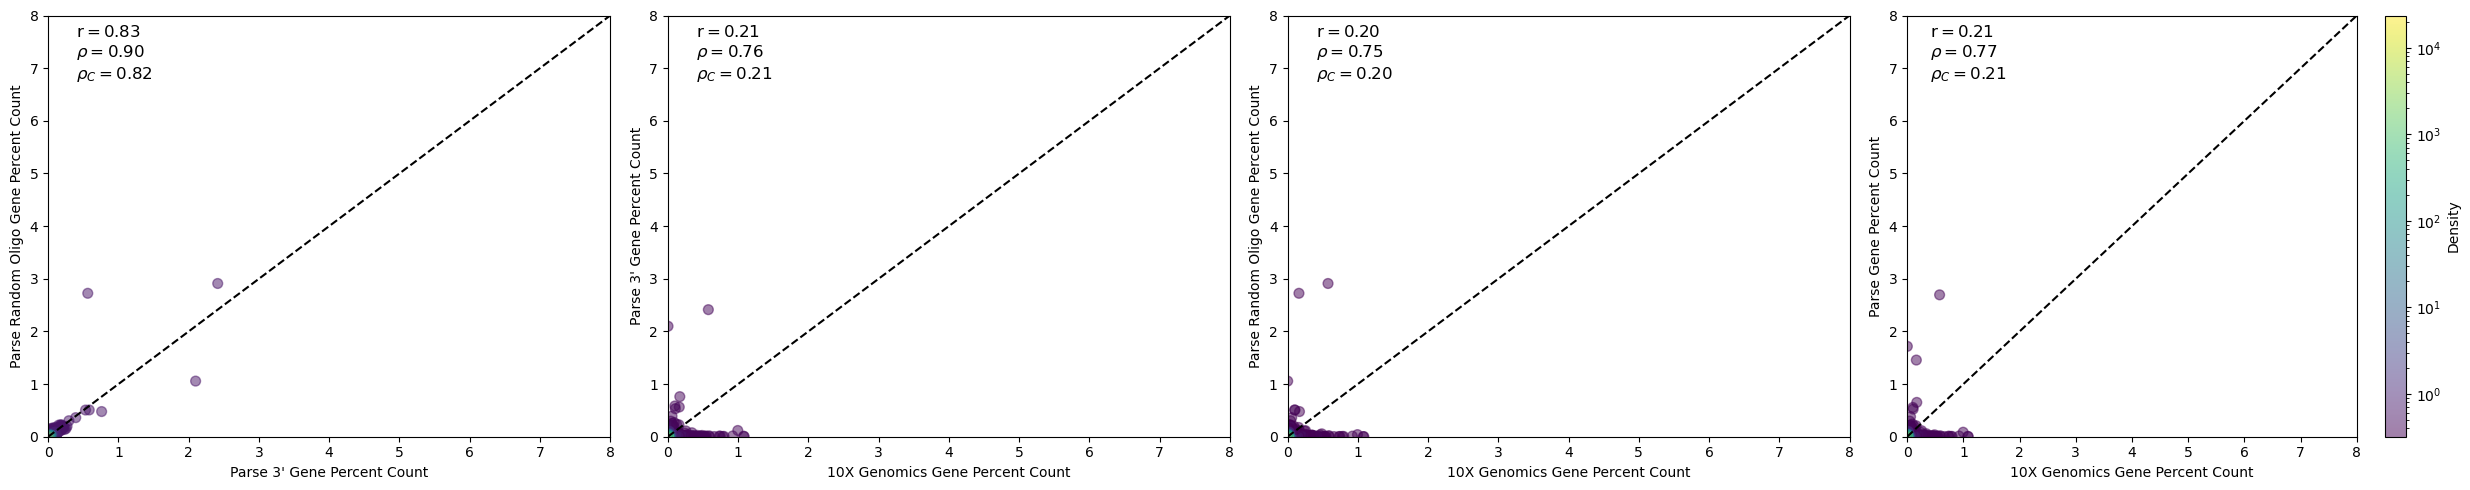

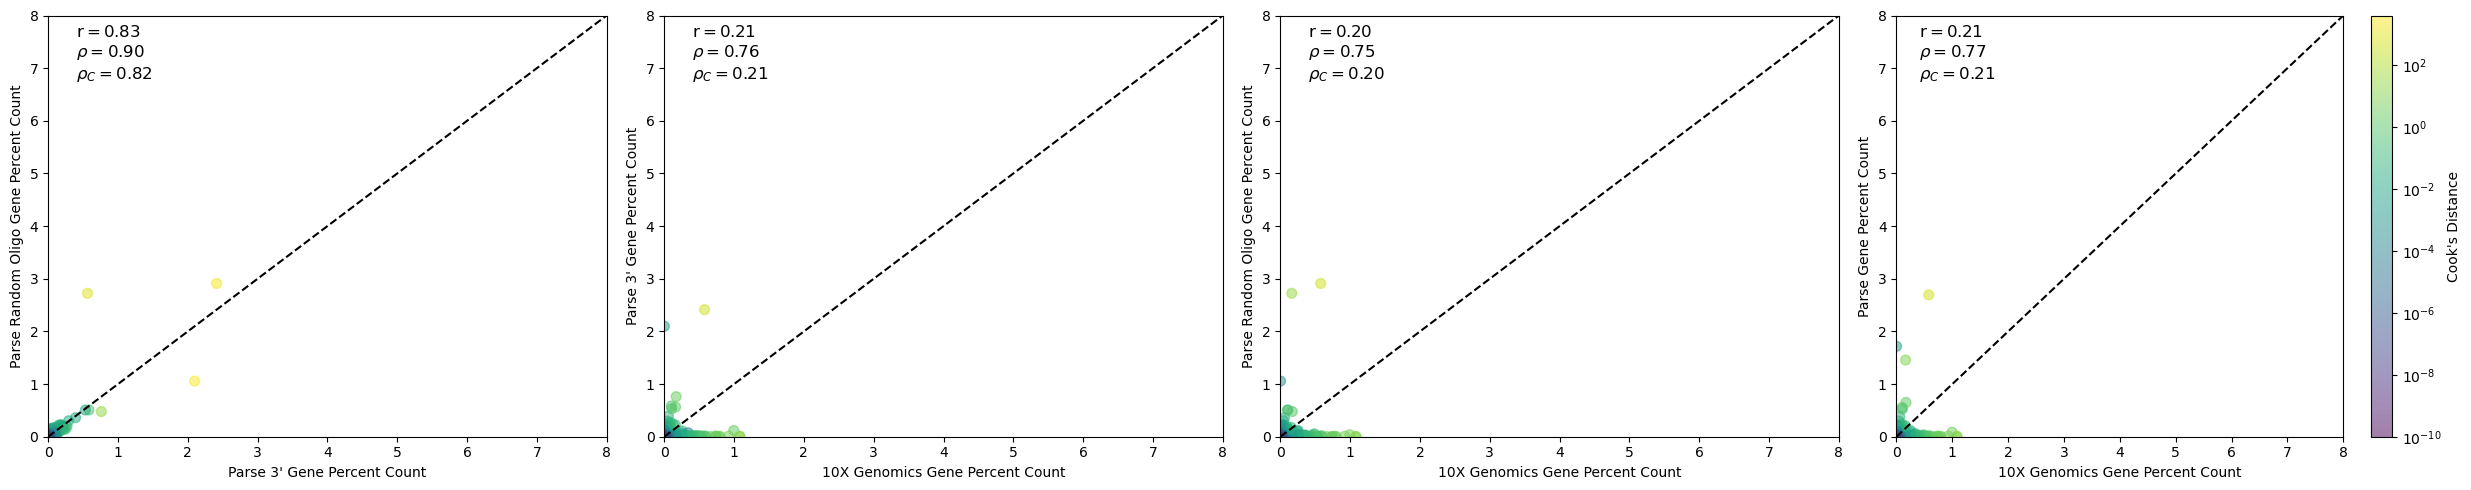

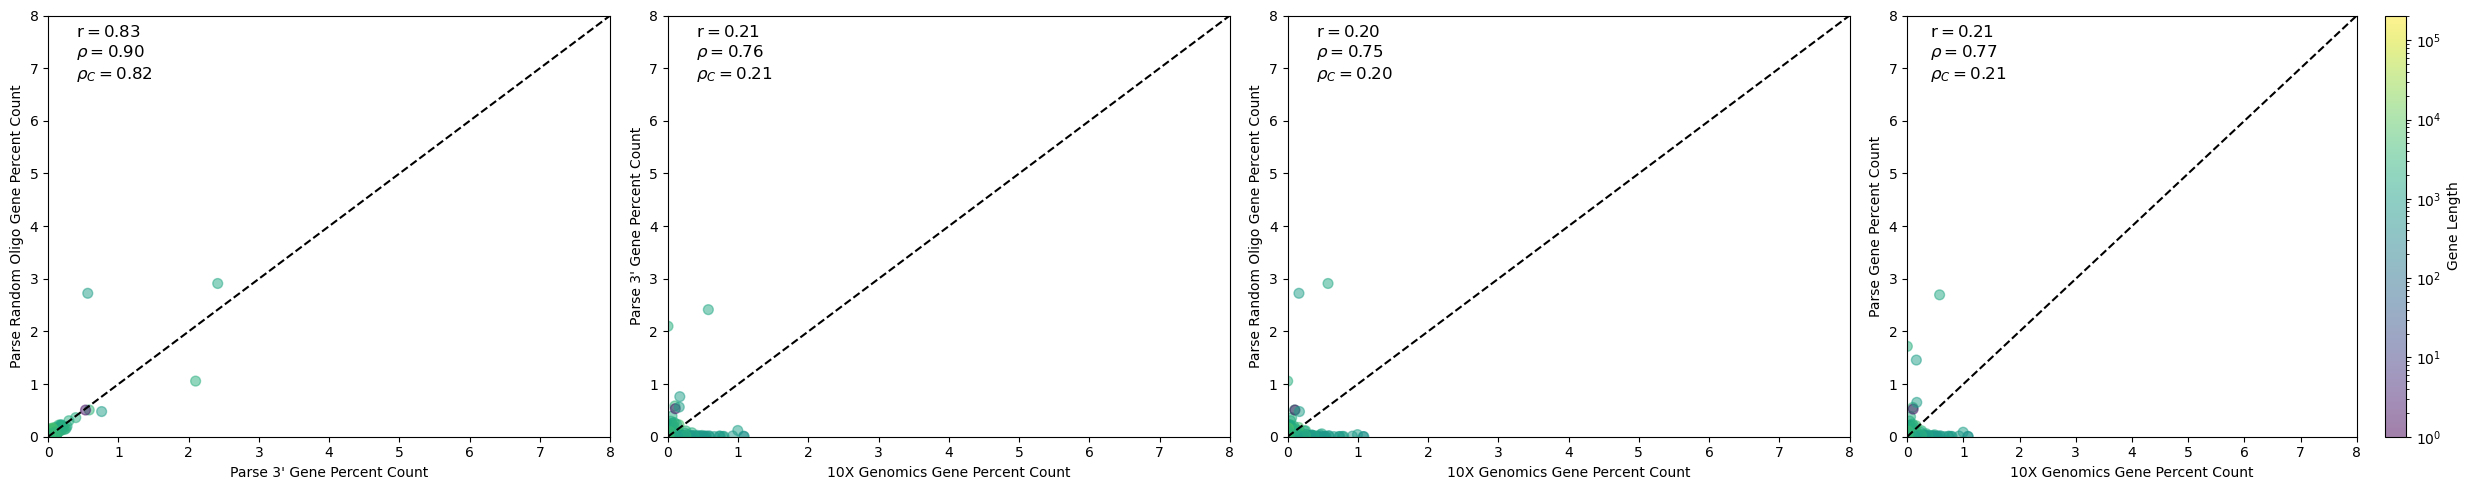

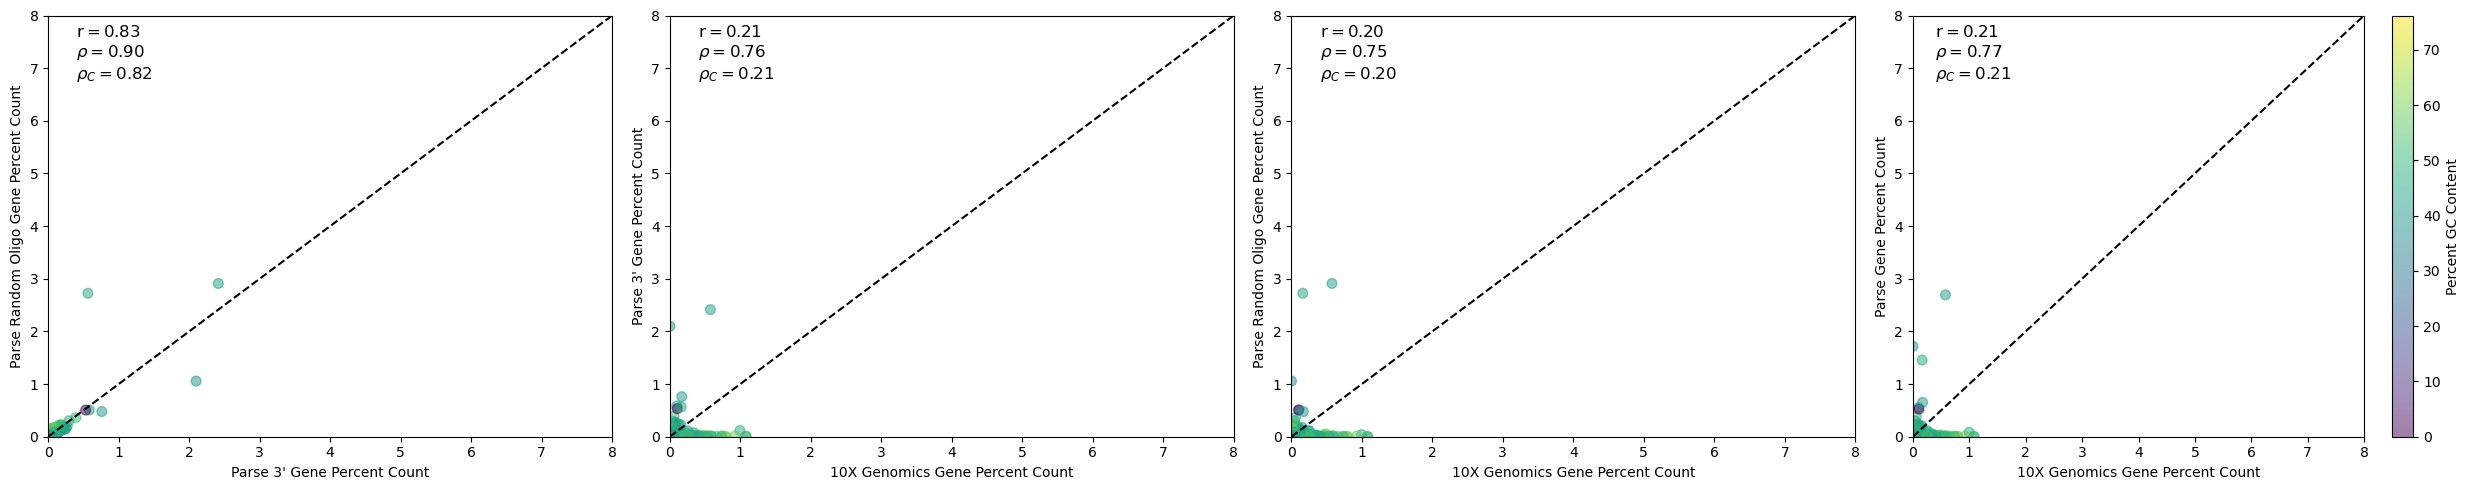

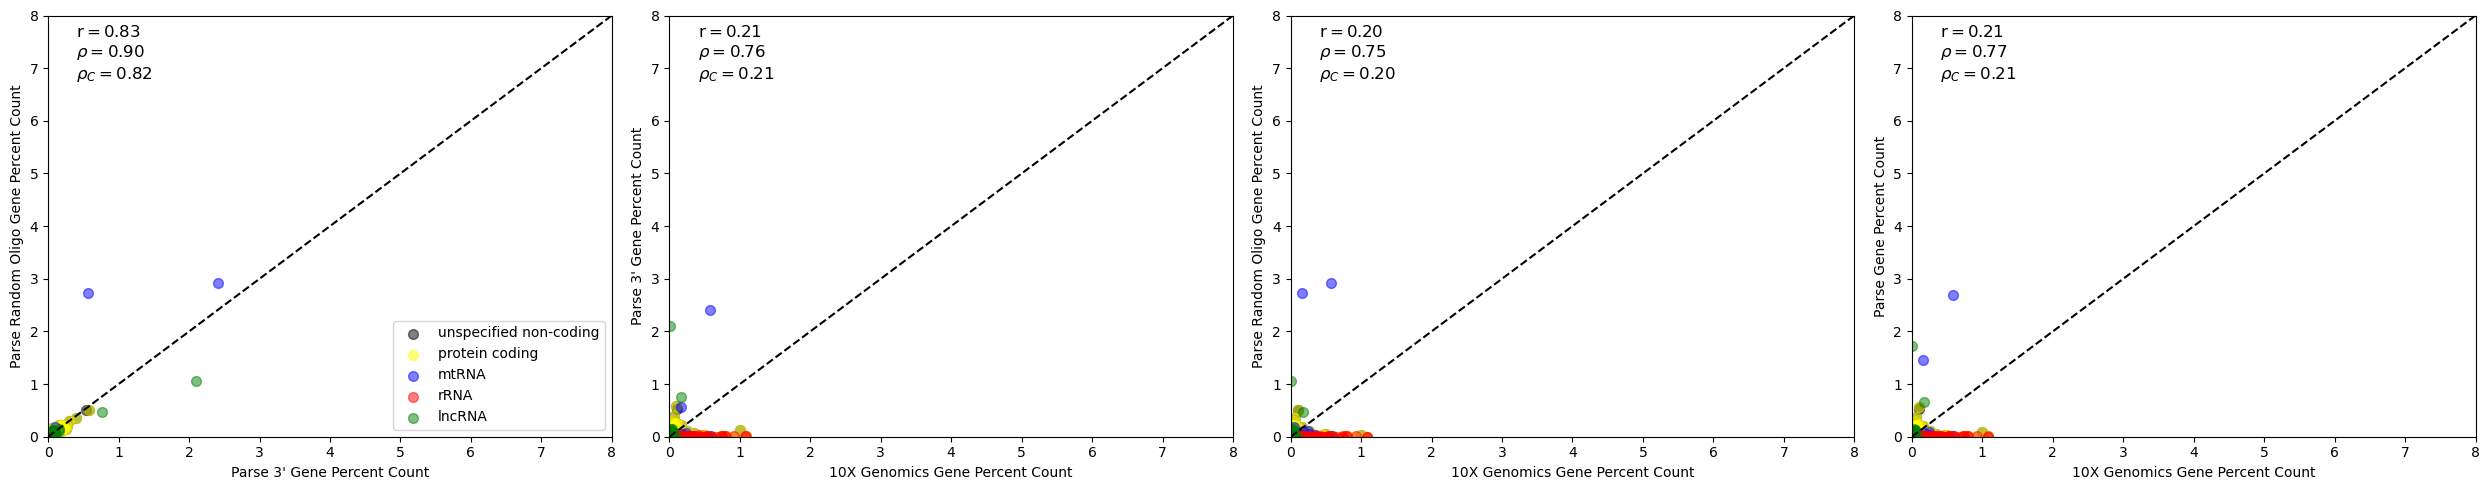

In [27]:
compare_names, compare_dfs = plotting.compare(datasets, 8)

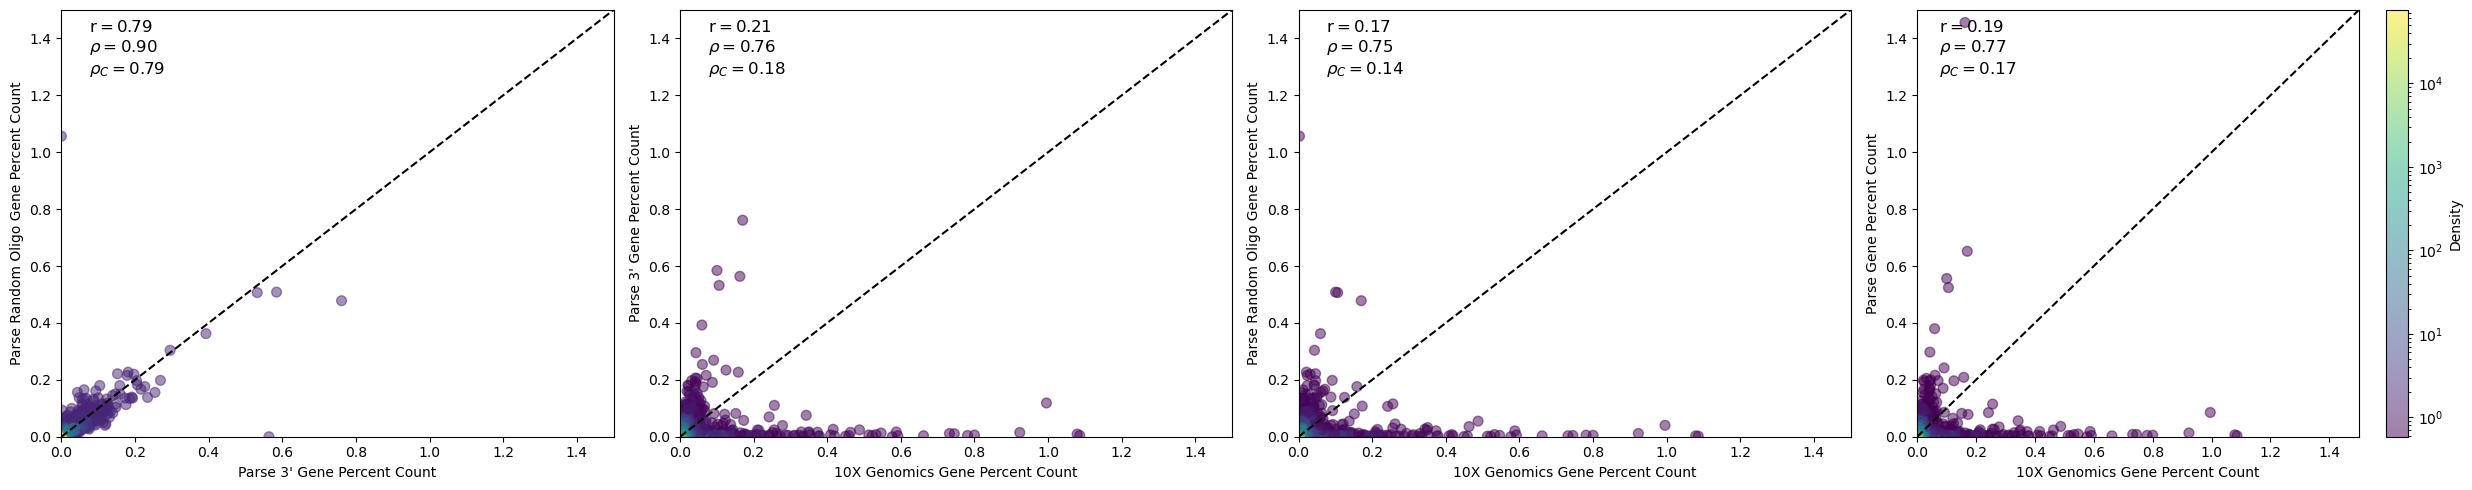

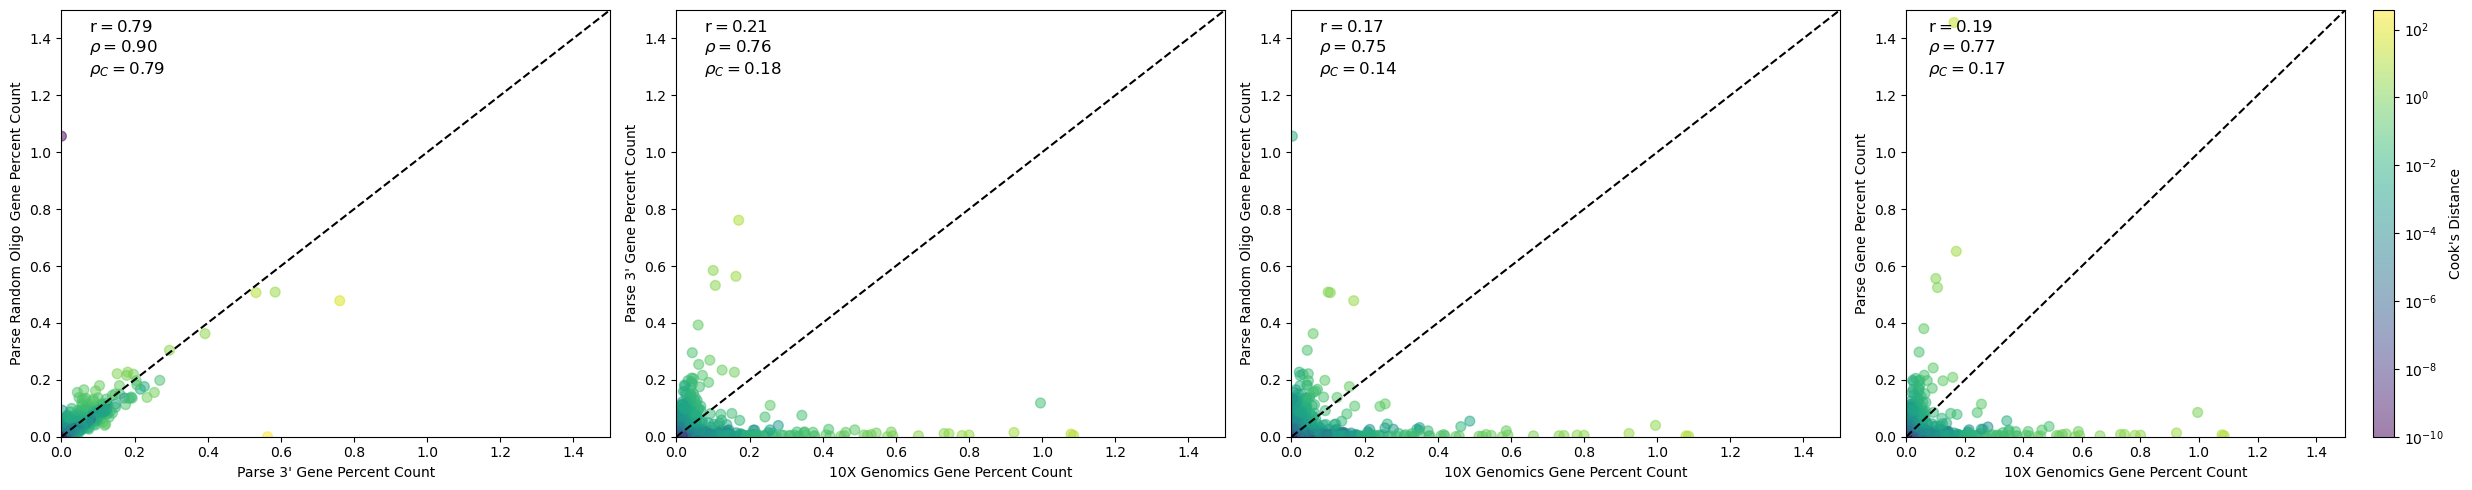

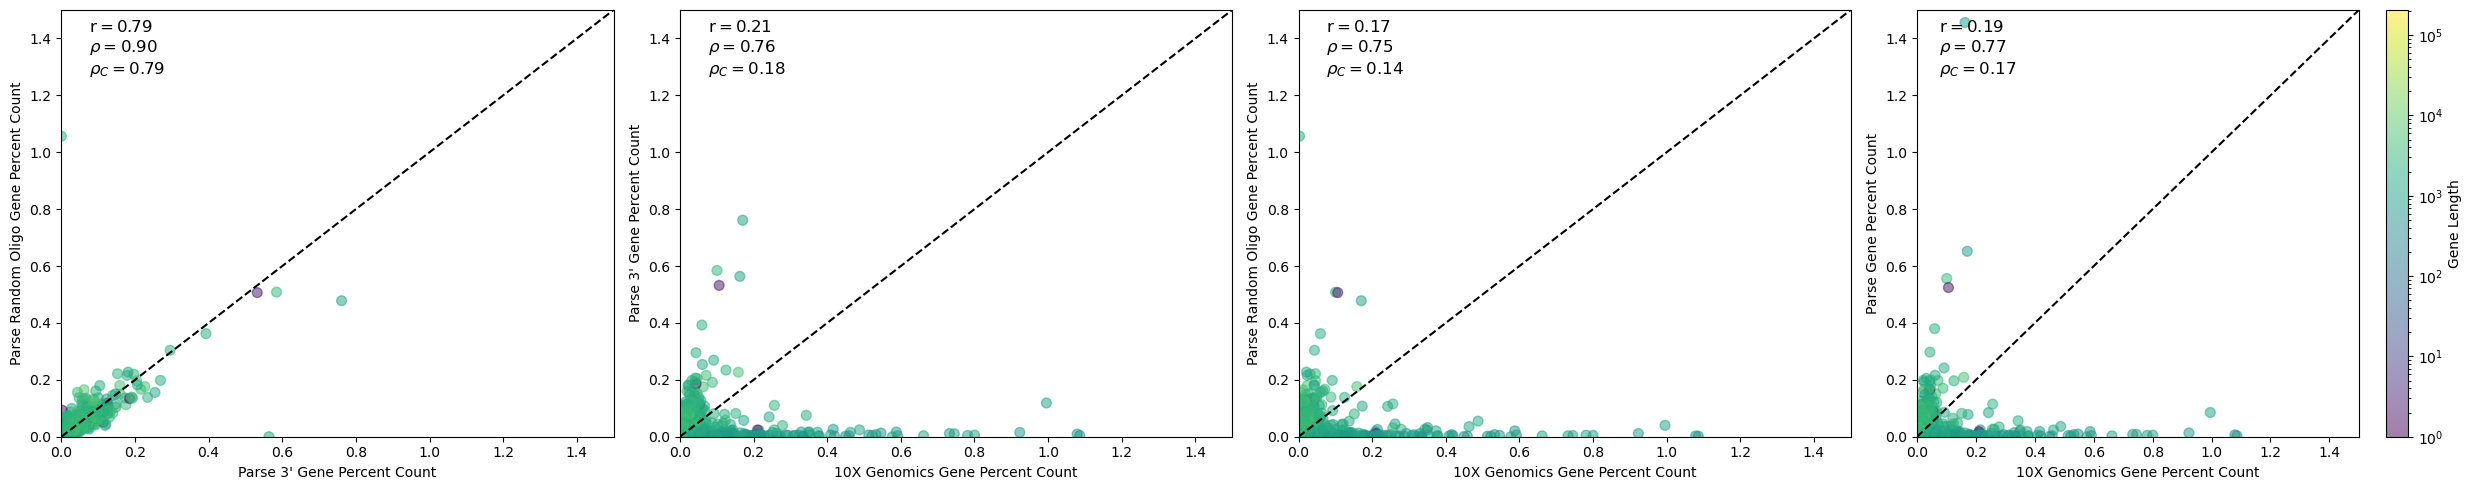

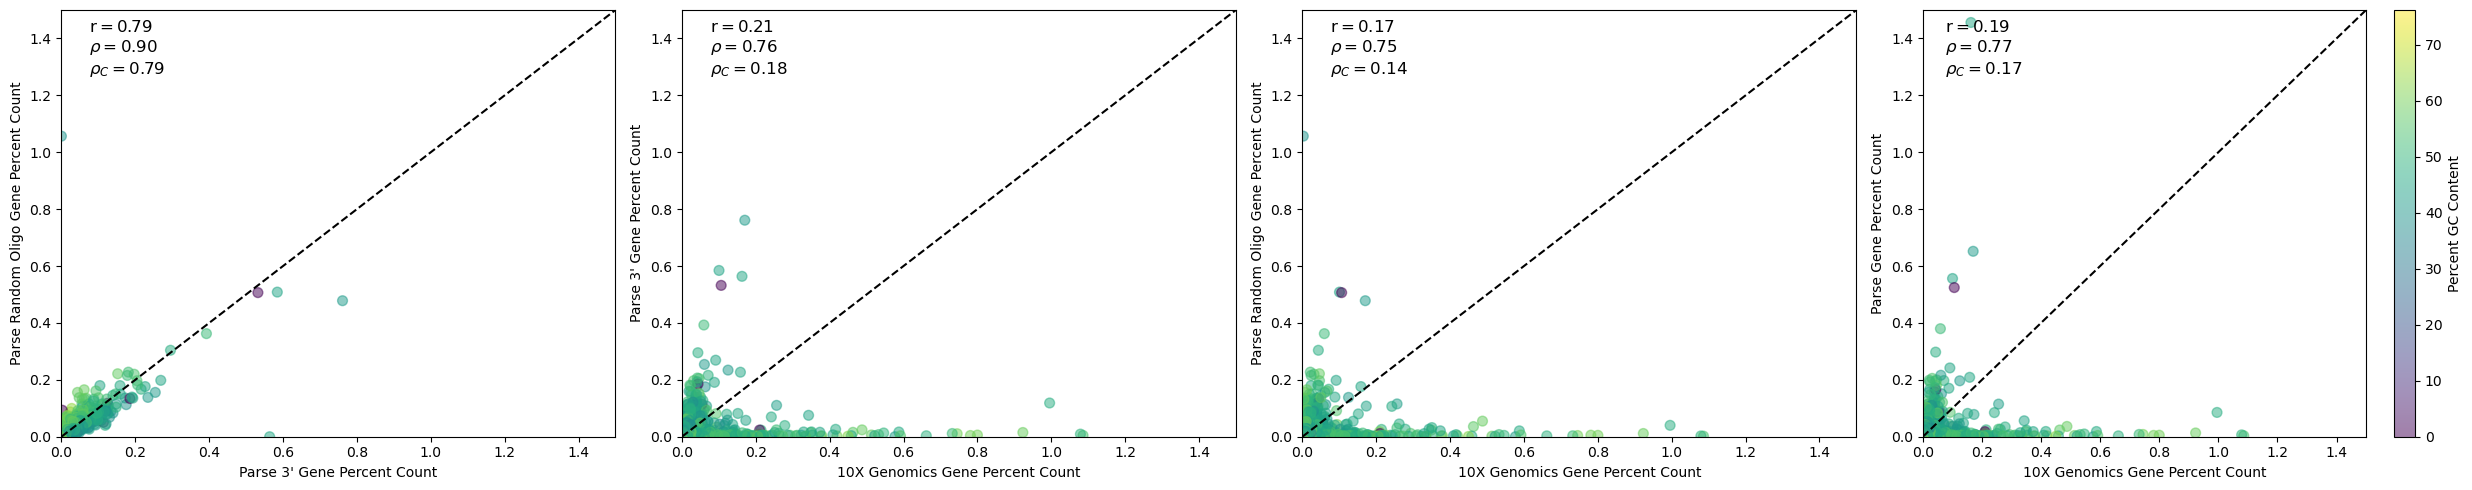

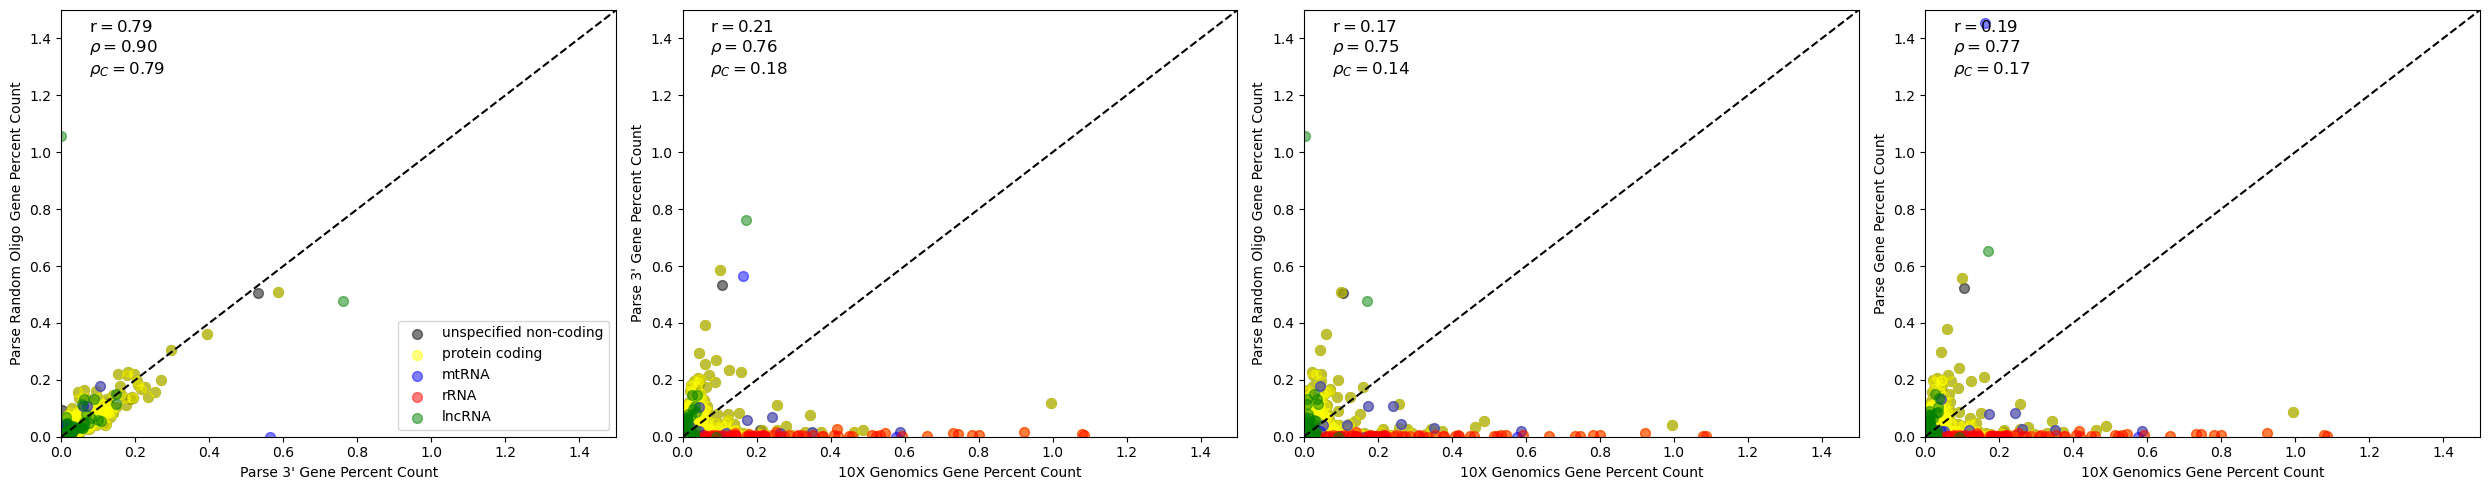

In [28]:
_, _ = plotting.compare(datasets, 1.5)

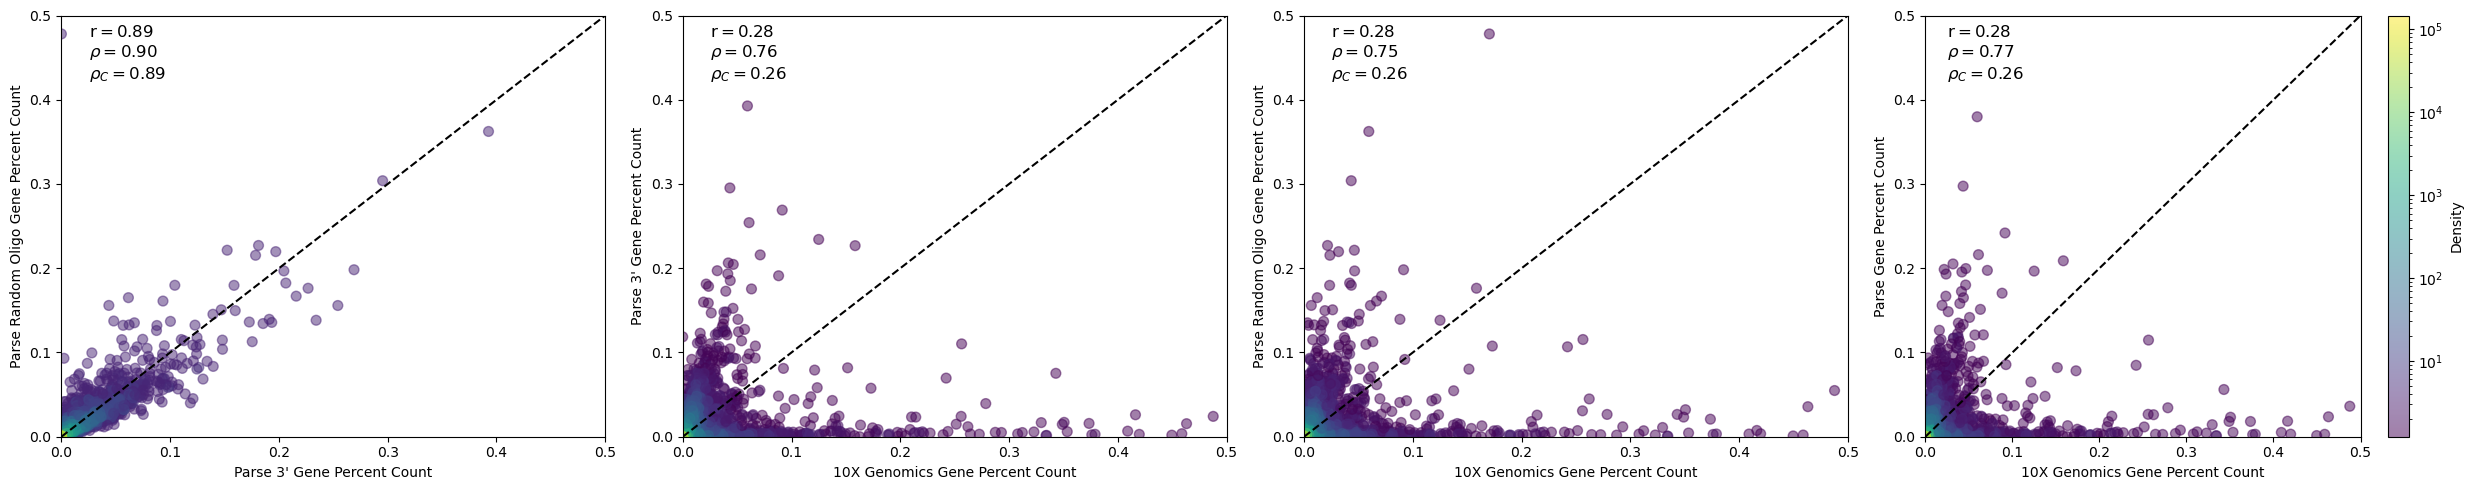

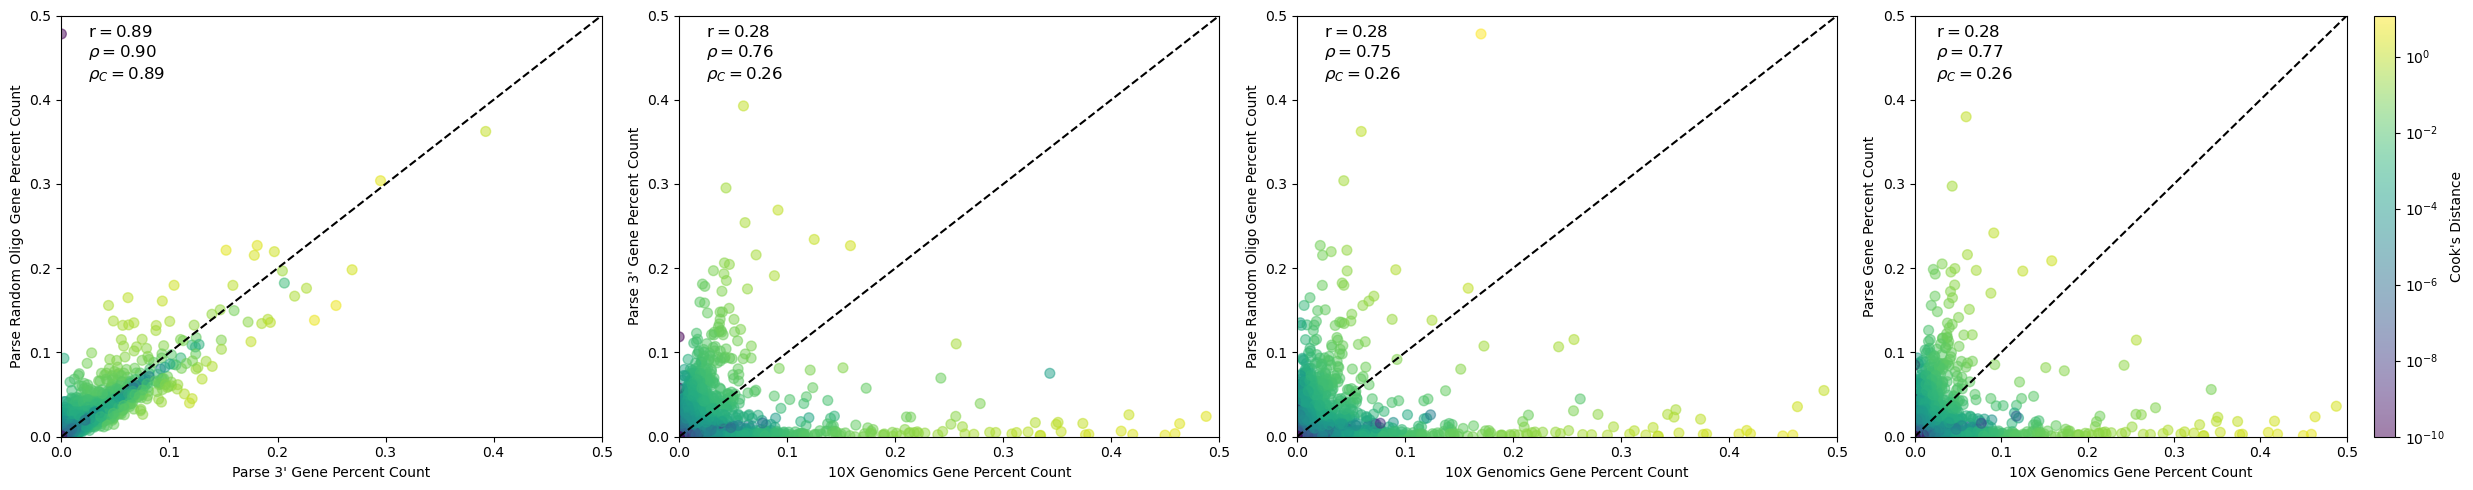

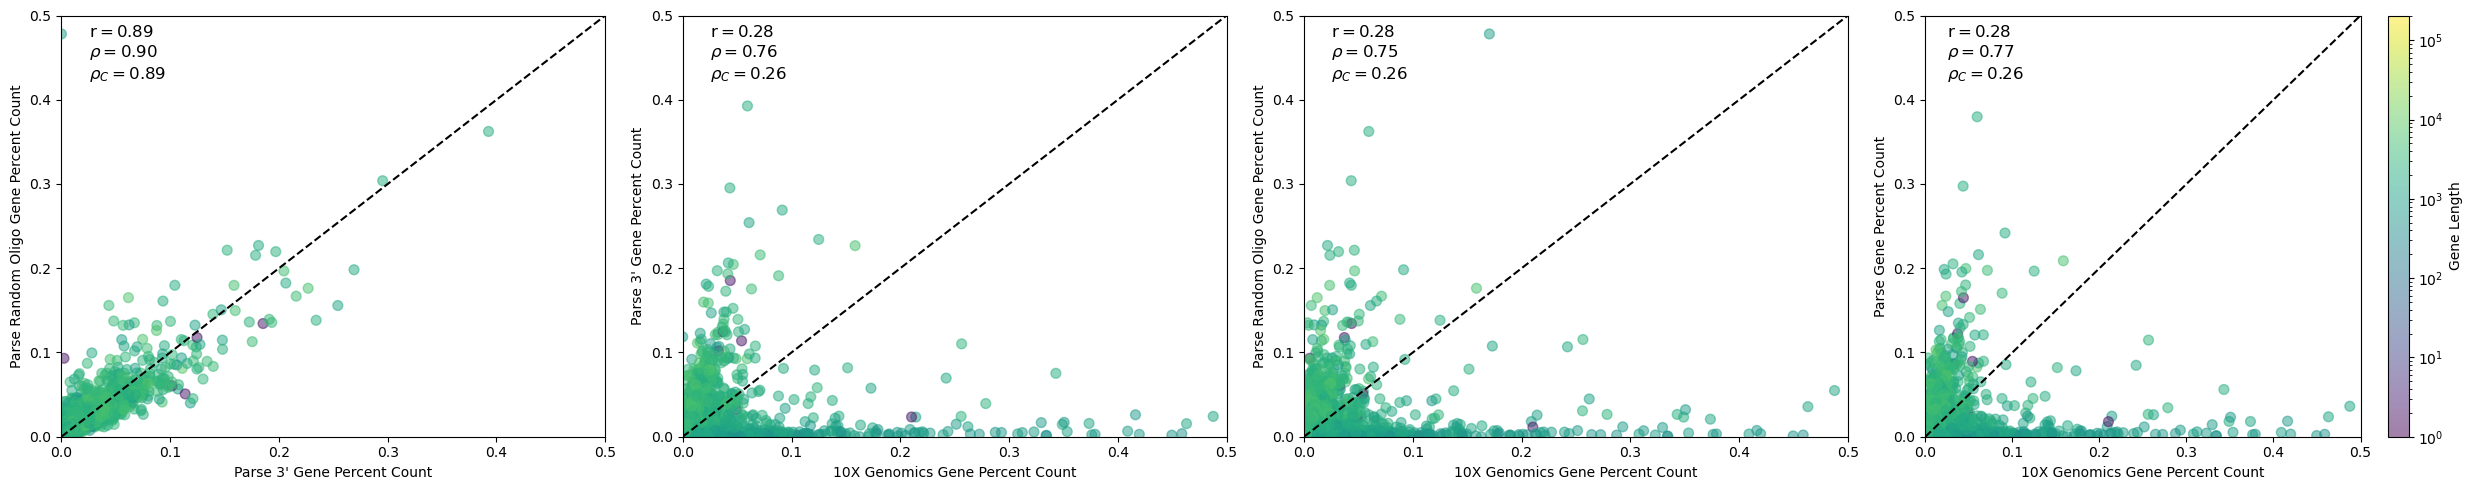

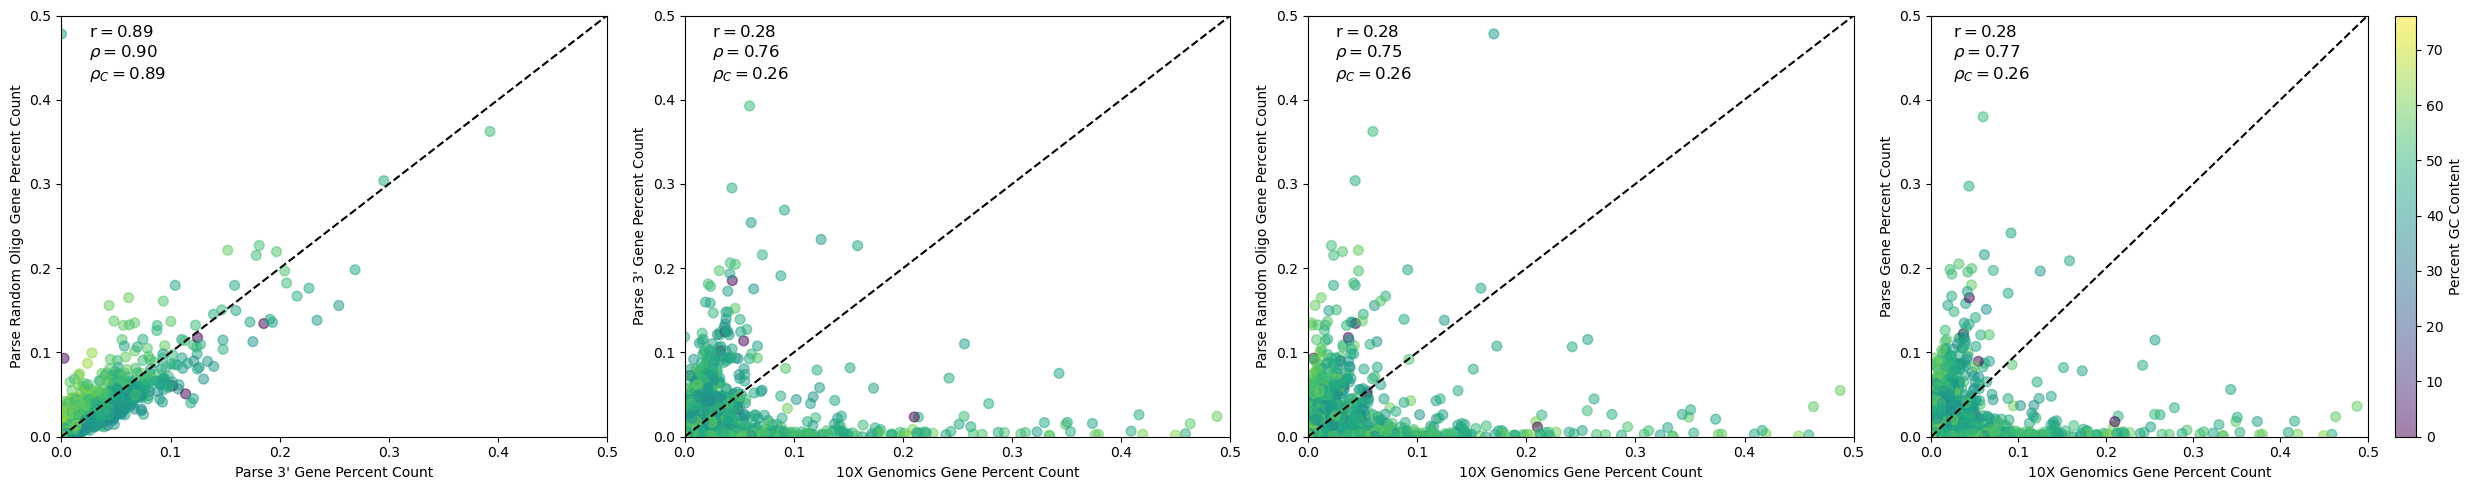

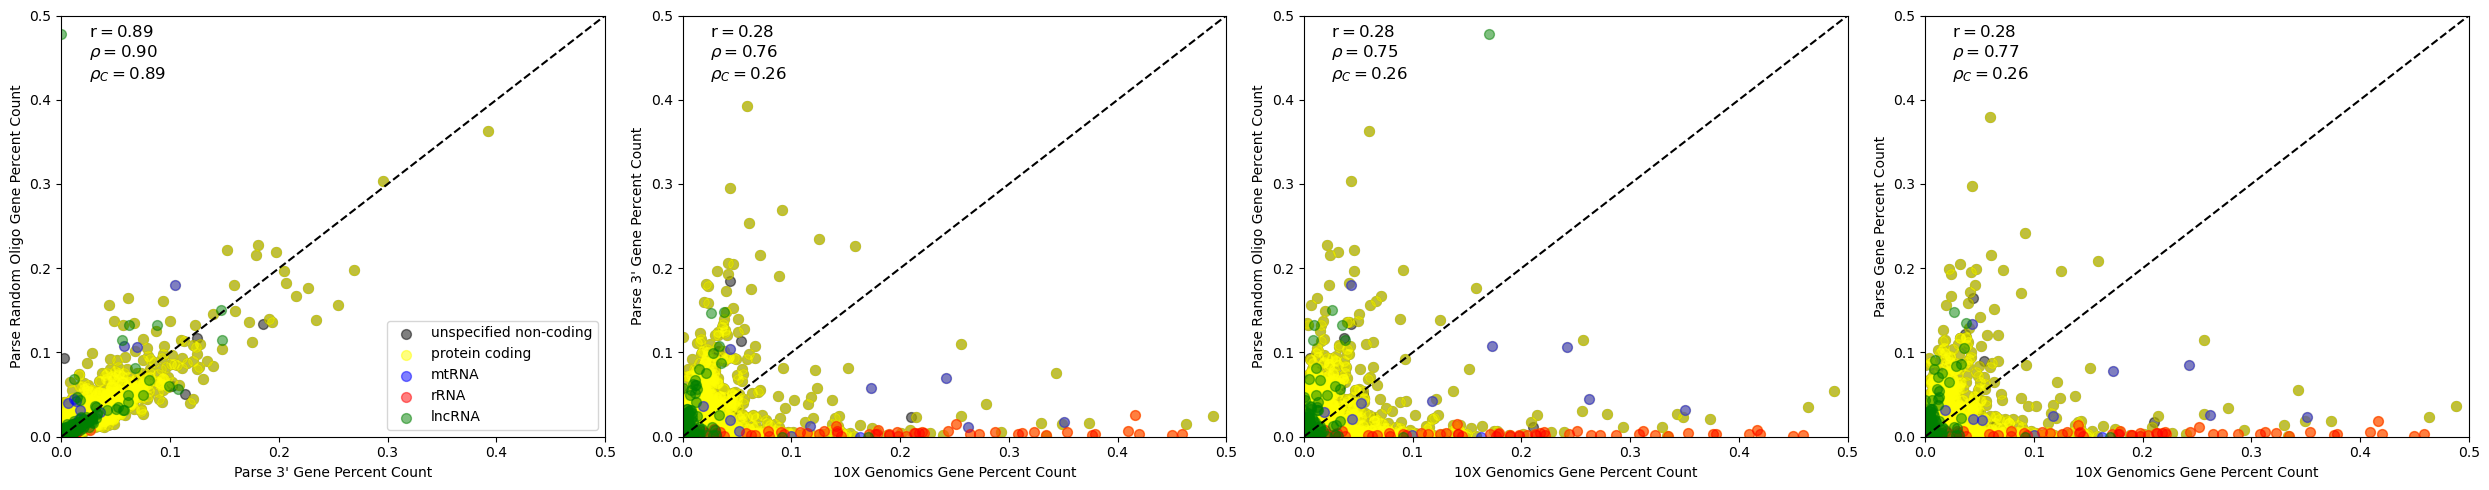

In [29]:
_, _ = plotting.compare(datasets, 0.5)

In [30]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)

full_gene_info_path = 'gene_data/gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)

In [31]:
cell_thresh = 10

contents = plotting.generate_upset(datasets, gene_info, cell_thresh)

In [32]:
# Extract gene subsets that were interesting in the upset plot

genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_PO = contents['gene_ids'][~contents['10x']& 
                                ~contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_PO = genes_PO.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

set_names = ['10X', 'Parse and Parse Random Oligo', 'Parse, and Parse Random Oligo, and Parse PolyT', 'All Methods']
gene_sets = [genes_10x, genes_PO, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

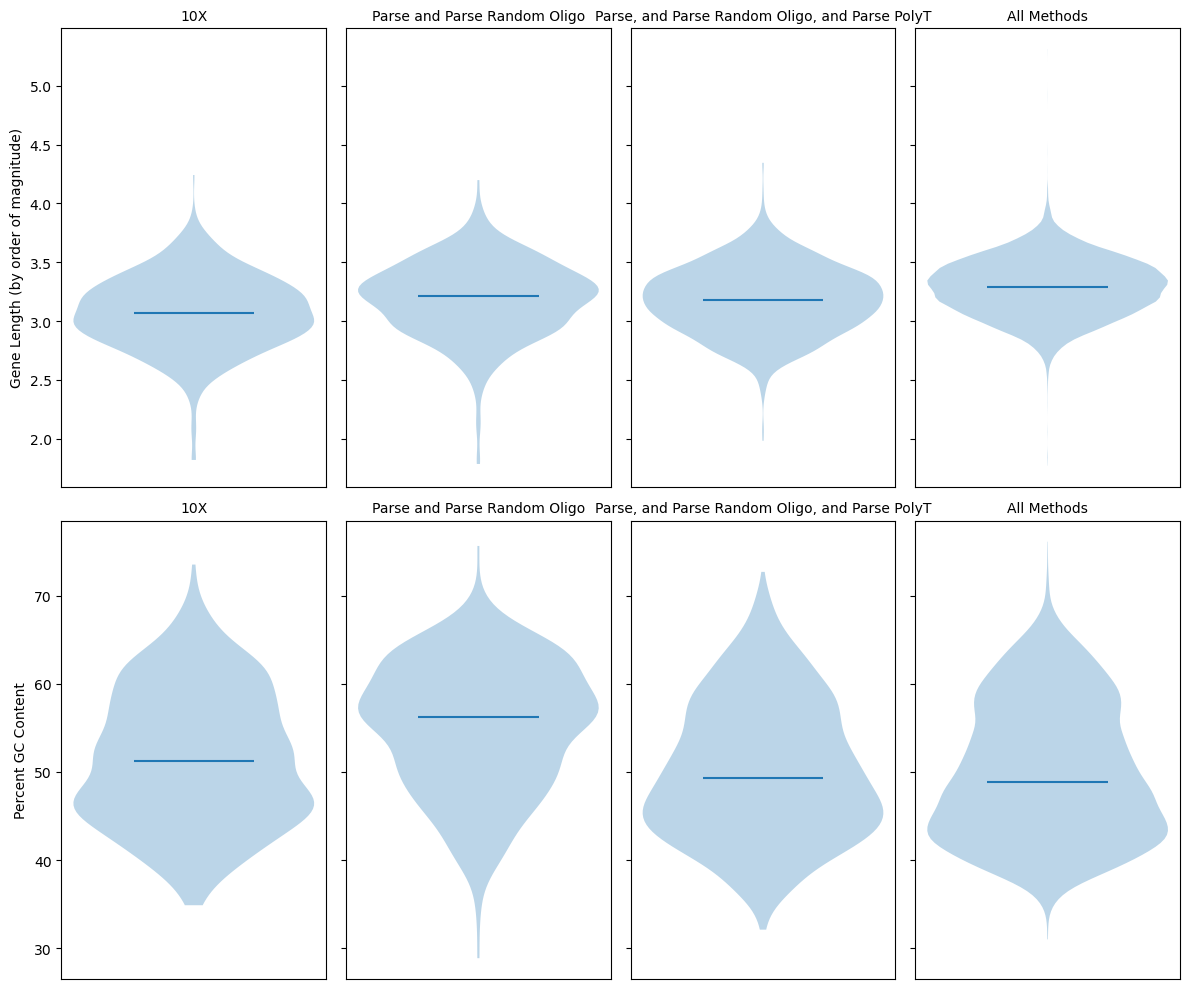

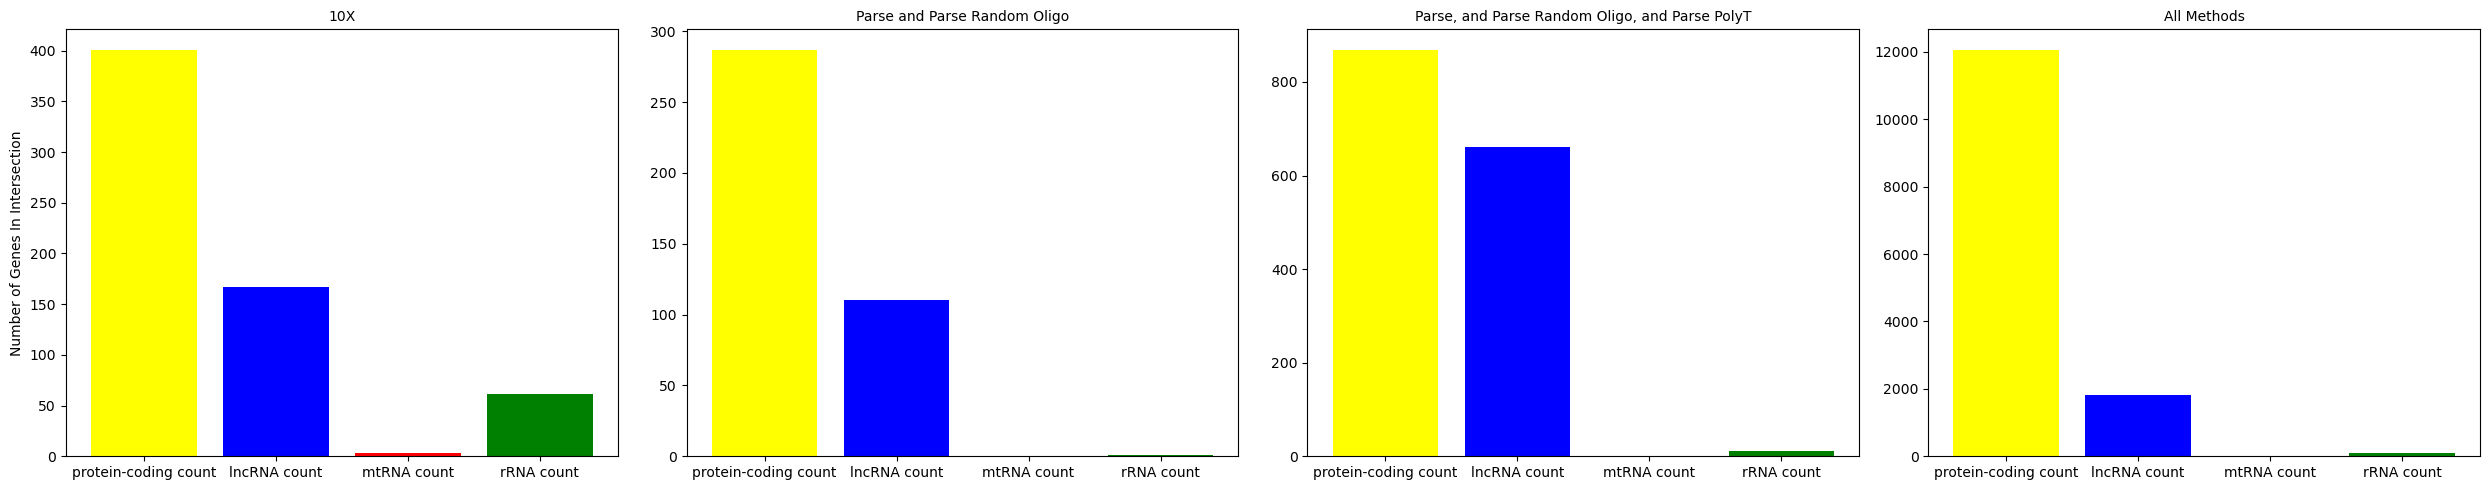

In [33]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)

In [34]:
# Look at top 1000 genes for each method instead of all
contents = plotting.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)

In [35]:
genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

geneset_names = ['10X', 'Parse Methods', 'All Methods']
genesets = [genes_10x, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

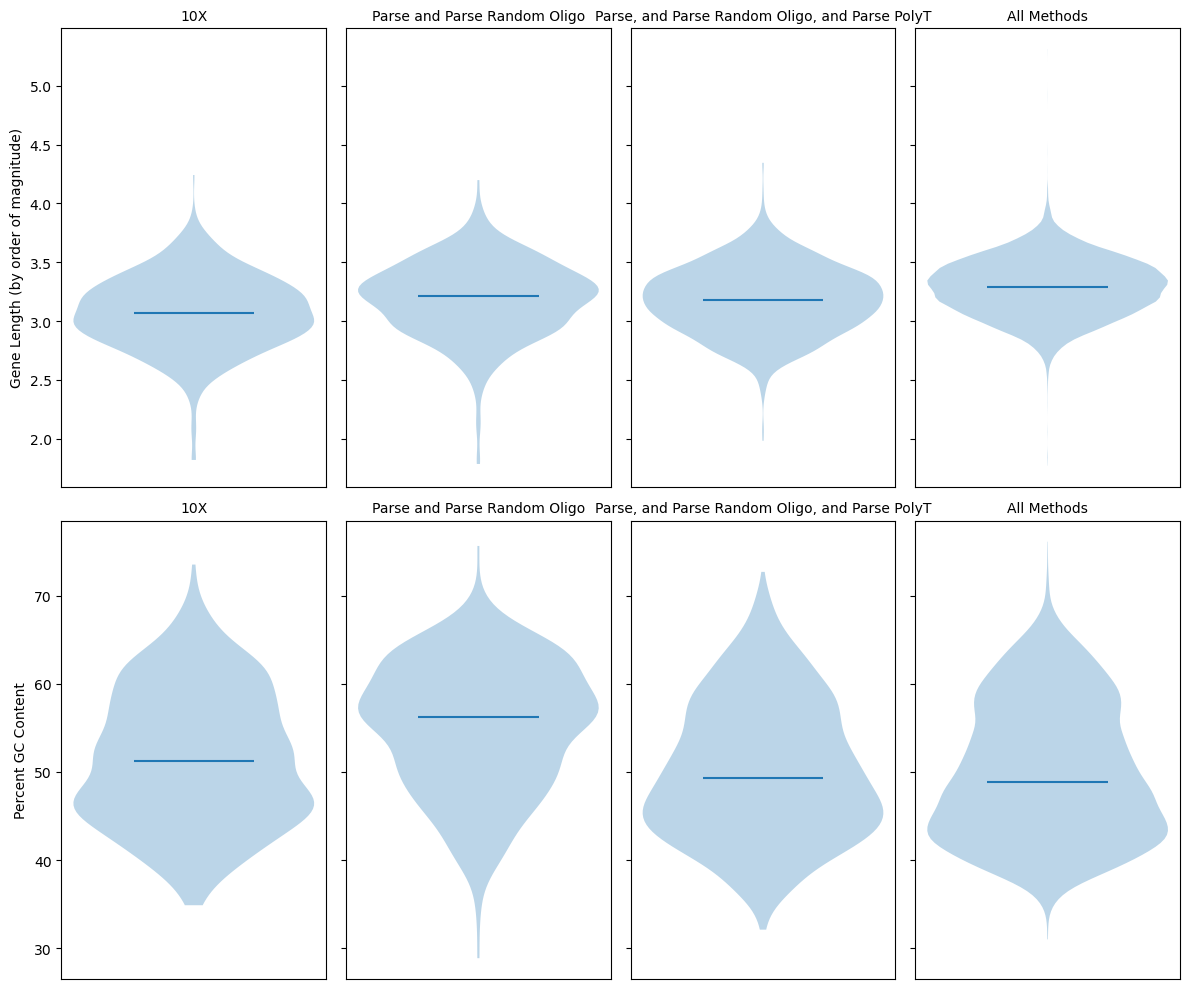

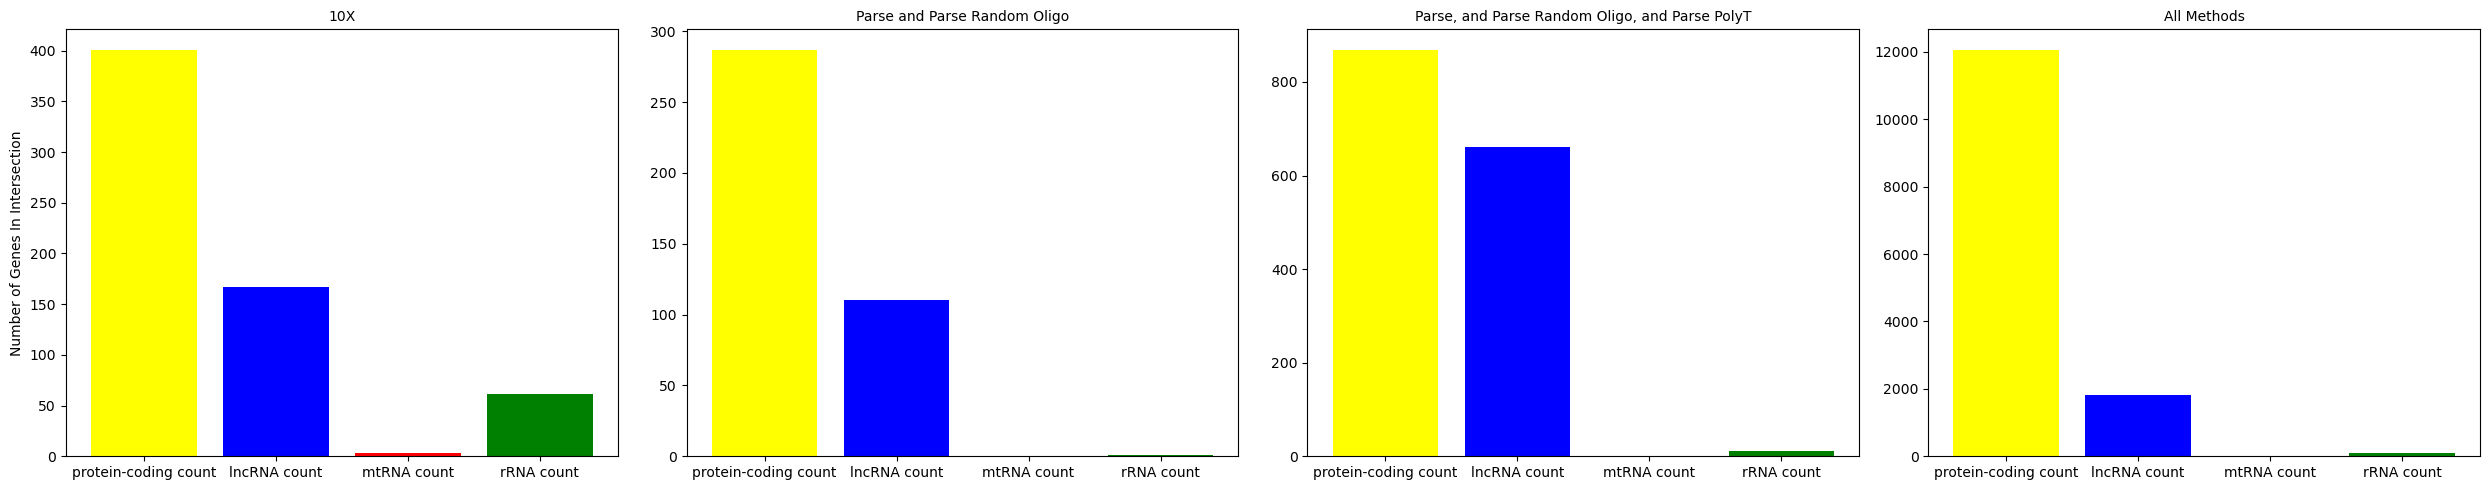

In [36]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)